# 3D Heterogeneous SSR (HYPRE + Profiler)

## Notes Before Running
- Activate local environment: `source setup/activate_optimized_octave.sh`
- In Jupyter, select `Octave (local-rsb)` kernel.
- This notebook follows the COMSOL notebook structure with HYPRE + profiler instrumentation.

In [1]:
%plot -f png -r 600
% Load sparsersb for multithreaded sparse matrix-vector products
pkg load sparsersb;

% Configure toolkit for both GUI and headless Jupyter environments.
try
    graphics_toolkit('qt');
catch
    graphics_toolkit('gnuplot');
end
set(0, 'defaultfigurevisible', 'off');

fprintf('Working directory: %s\n', pwd);
fprintf('Graphics toolkit: %s\n', graphics_toolkit());


Working directory: /home/beremi/repos/slope_stability/slope_stability
Graphics toolkit: qt


## 1) Main Input Data

In [2]:
elem_type = 'P2';
Davis_type = 'B';

% [c0, phi, psi, young, poisson, gamma_sat, gamma_unsat]
mat_props = [15, 30,  0, 10000, 0.33, 19, 19;  % Cover layer
    15, 38,  0, 50000, 0.30, 22, 22;  % General foundation
    10, 35,  0, 50000, 0.30, 21, 21;  % Relatively weak foundation
    18, 32,  0, 20000, 0.33, 20, 20]; % General slope mass

file_path = 'meshes/SSR_hetero_ada_L1.h5';


## 2) Reference Element Data and Mesh Load

In [3]:
[Xi, WF] = ASSEMBLY.quadrature_volume_3D(elem_type);
[HatP, DHatP1, DHatP2, DHatP3] = ASSEMBLY.local_basis_volume_3D(elem_type, Xi);

[coord, elem, surf, Q, material_identifier] = MESH.load_mesh_P2(file_path);
[coord, elem, surf, Q] = MESH.reorder_mesh(coord, elem, surf, Q);

n_n = size(coord,2);
n_unknown = length(coord(Q));
n_e = size(elem,2);
n_q = length(WF);
n_int = n_e * n_q;

fprintf('\nMesh data:');
fprintf('  number of nodes =%d ', n_n);
fprintf('  number of unknowns =%d ', n_unknown);
fprintf('  number of elements =%d ', n_e);
fprintf('  number of integration points =%d ', n_int);
fprintf('\n');


  Mesh reordering (symrcm): bandwidth 22904 -> 27686 (0.8x reduction)

Mesh data:  number of nodes =27605   number of unknowns =80362   number of elements =18419   number of integration points =202609 


### Mesh Preview

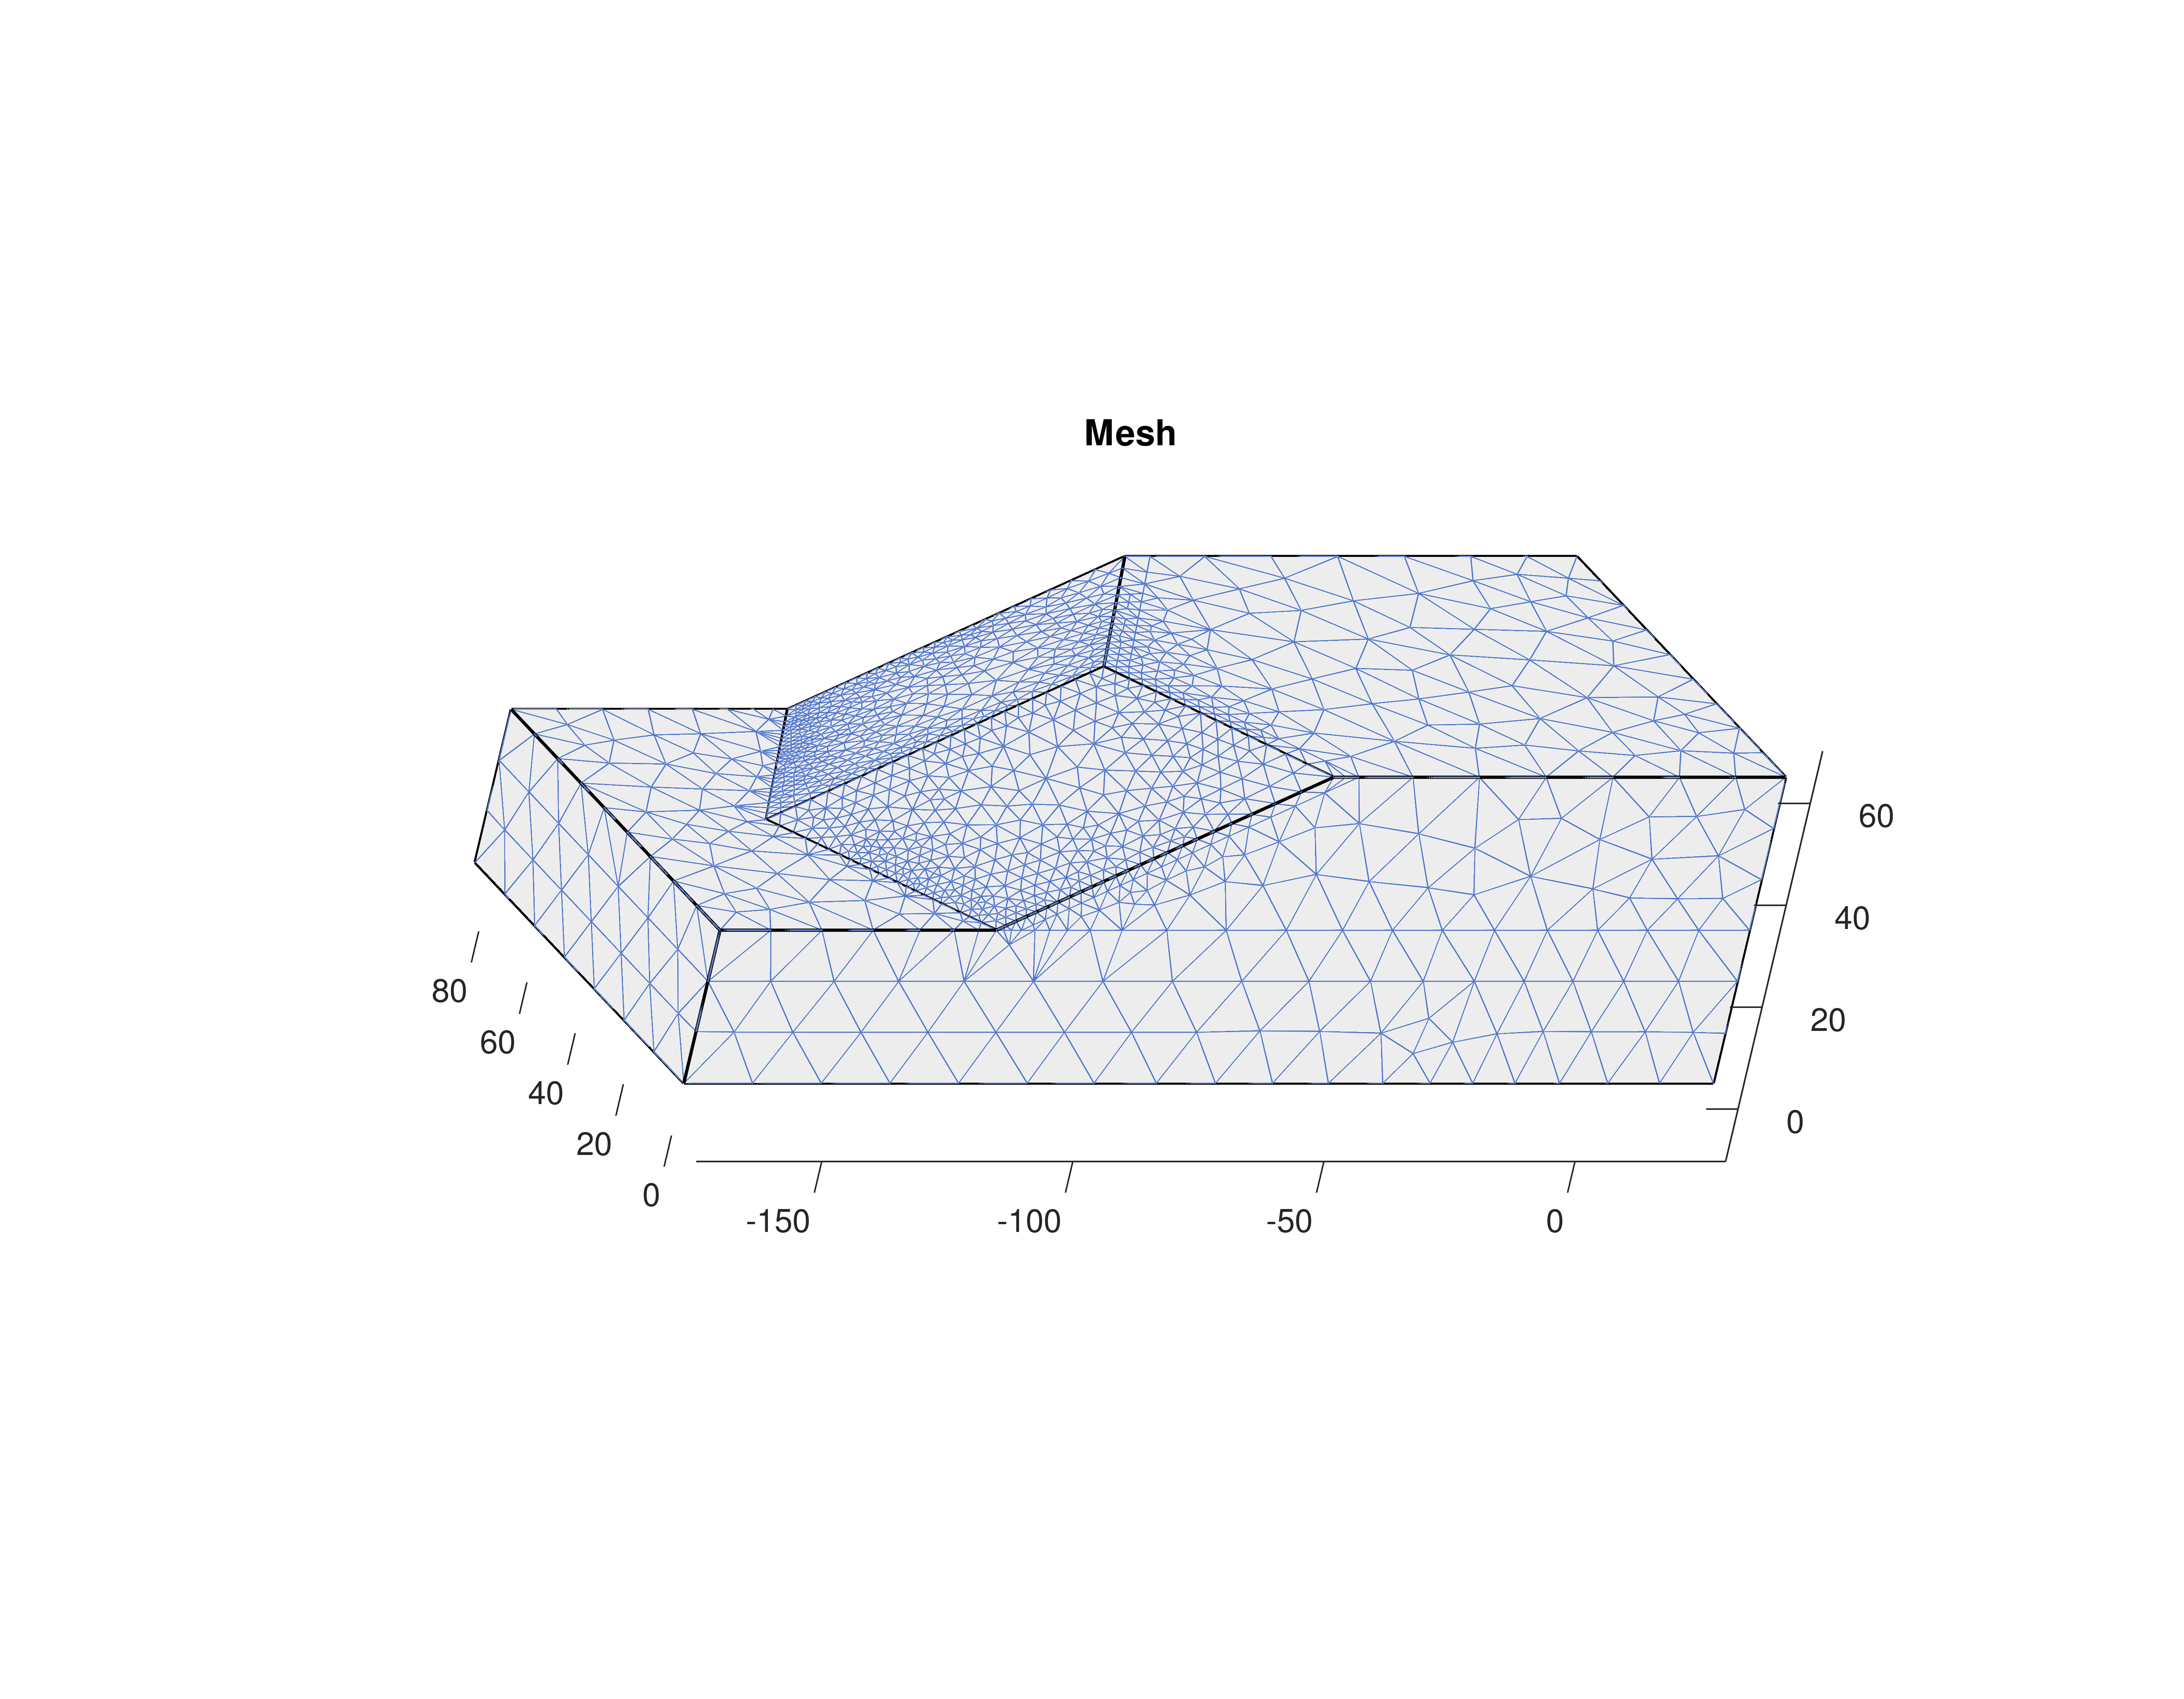

In [4]:
plotter = VIZ.SolutionPlotter(coord, elem, surf, 'comsol');
plotter.plot_mesh();
drawnow;


## 3) Mechanical Material Fields and Assembly

In [5]:
fields = {'c0', 'phi', 'psi', 'young', 'poisson', 'gamma_sat', 'gamma_unsat'};
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

saturation = true(1, n_int);
[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material_identifier, saturation, n_q, materials);

[K_elast, B, WEIGHT, DPhi1_out, DPhi2_out, DPhi3_out] = ASSEMBLY.elastic_stiffness_matrix_3D(...
    elem, coord, shear, bulk, DHatP1, DHatP2, DHatP3, WF);

f_V_int = [zeros(1, n_int); -gamma; zeros(1, n_int)];
f_V = ASSEMBLY.vector_volume_3D(elem, coord, f_V_int, HatP, WEIGHT);


In [6]:
plotter.set_strain_data(B, Xi);


## 4) Continuation, Newton, and Linear Solver Parameters

In [7]:
lambda_init = 1.0;
d_lambda_init = 0.1;
d_lambda_min = 1e-3;
d_lambda_diff_scaled_min = 0.001;
omega_max_stop = 1.20e7;
step_max = 100;

it_newt_max = 200;
it_damp_max = 10;
tol = 1e-4;
r_min = 1e-4;

% agmg folder is baked into LINEAR_SOLVERS.set_linear_solver
solver_type = 'DFGMRES_HYPRE_BOOMERAMG';

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 0;

boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

linear_system_solver = LINEAR_SOLVERS.set_linear_solver(solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, ...
    linear_solver_printing, Q, coord, boomeramg_opts);

n_strain = 6;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(...
    B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, 3);

constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out, DPhi3_out);

profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;


Element data set: n_p=10, n_e=18419, n_q=11, mex=1


## 5) Run SSR Continuation (Indirect Only)

In [8]:
direct_on = 0;
indirect_on = 1;

if indirect_on
    fprintf('\n Indirect continuation method\n');
    tic;
    [U3, lambda_hist3, omega_hist3, Umax_hist3, stats] = CONTINUATION.SSR_indirect_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        omega_max_stop, it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf('Running_time = %f \n', time_run);
end

if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end



 Indirect continuation method
Initialising K_r(Q,Q) sparse pattern ... done  (10.1 s, n_Q = 80362, nnz = 6385052)
Building element scatter map ... done  (0.9 s, n_local_dof=30, map_size=133 MB)
Init step 1: lambda=1
newton summary: status=converged, it=7, rel_resid=9.904509e-05, lin_it_total=19, wall_time=3.58 s
   lambda_init = 1, d_lambda_init = 0.1, omega_init = 6214942.4663
Init step 2: searching lambda2 from lambda1=1
newton summary: status=converged, it=5, rel_resid=7.213690e-05, lin_it_total=14, wall_time=2.30 s
   lambda1 = 1, lambda2 = 1.1, d_lambda = 0.1, omega1 = 6214942.4663, omega2 = 6229233.7537, d_omega = 14291.2874
Step 3: omega_target=6.24353e+06, d_omega=14291.3
newton_ind_SSR summary: status=converged, it=6, rel_resid=1.672400e-05, lin_it_total=[W:11,V:19], wall_time=3.28 s
  accepted: lambda=1.15986, d_lambda=0.0598569, d_lambda_diff_scaled=0.119714, omega=6.24353e+06, d_omega=14291.3, U_max=0.829955
Step 4: omega_target=6.27211e+06, d_omega=28582.6
newton_ind_SSR 

## Profiler Summary

In [9]:
profiler.print_summary();



  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
     70.45s  45.2%    262  DFGMRES.solve
     25.09s  16.1%    122  DFGMRES.update_preconditioner
     16.35s  10.5%    371  CONSTITUTIVE.stress
     12.62s   8.1%    521  CONSTITUTIVE.build_F
      9.05s   5.8%    483  CONSTITUTIVE.reduction
      7.66s   4.9%    150  CONSTITUTIVE.stress_tangent
      7.33s   4.7%    136  DFGMRES.A_orthogonalize
      4.58s   2.9%    136  CONSTITUTIVE.build_K_tangent_QQ_vals
      2.19s   1.4%     14  DFGMRES.setup_preconditioner
      0.53s   0.3%    266  DFGMRES.expand_deflation_basis
  --------- ------ ------  ------------------------------
    155.85s                TOTAL

  Sub-profile: DFGMRES.solve  (70.45s total, 262 calls)
  --------- ------ ------  ------------------------------
     48.45s  68.8%    193  precond_apply
      8.27s  11.7%    193  deflation_project
      5.53s   7.9%    262  init
      5.05s   7.2%    193  arnoldi

## 6) Mechanical Results and Convergence

Notebook workflow completed.


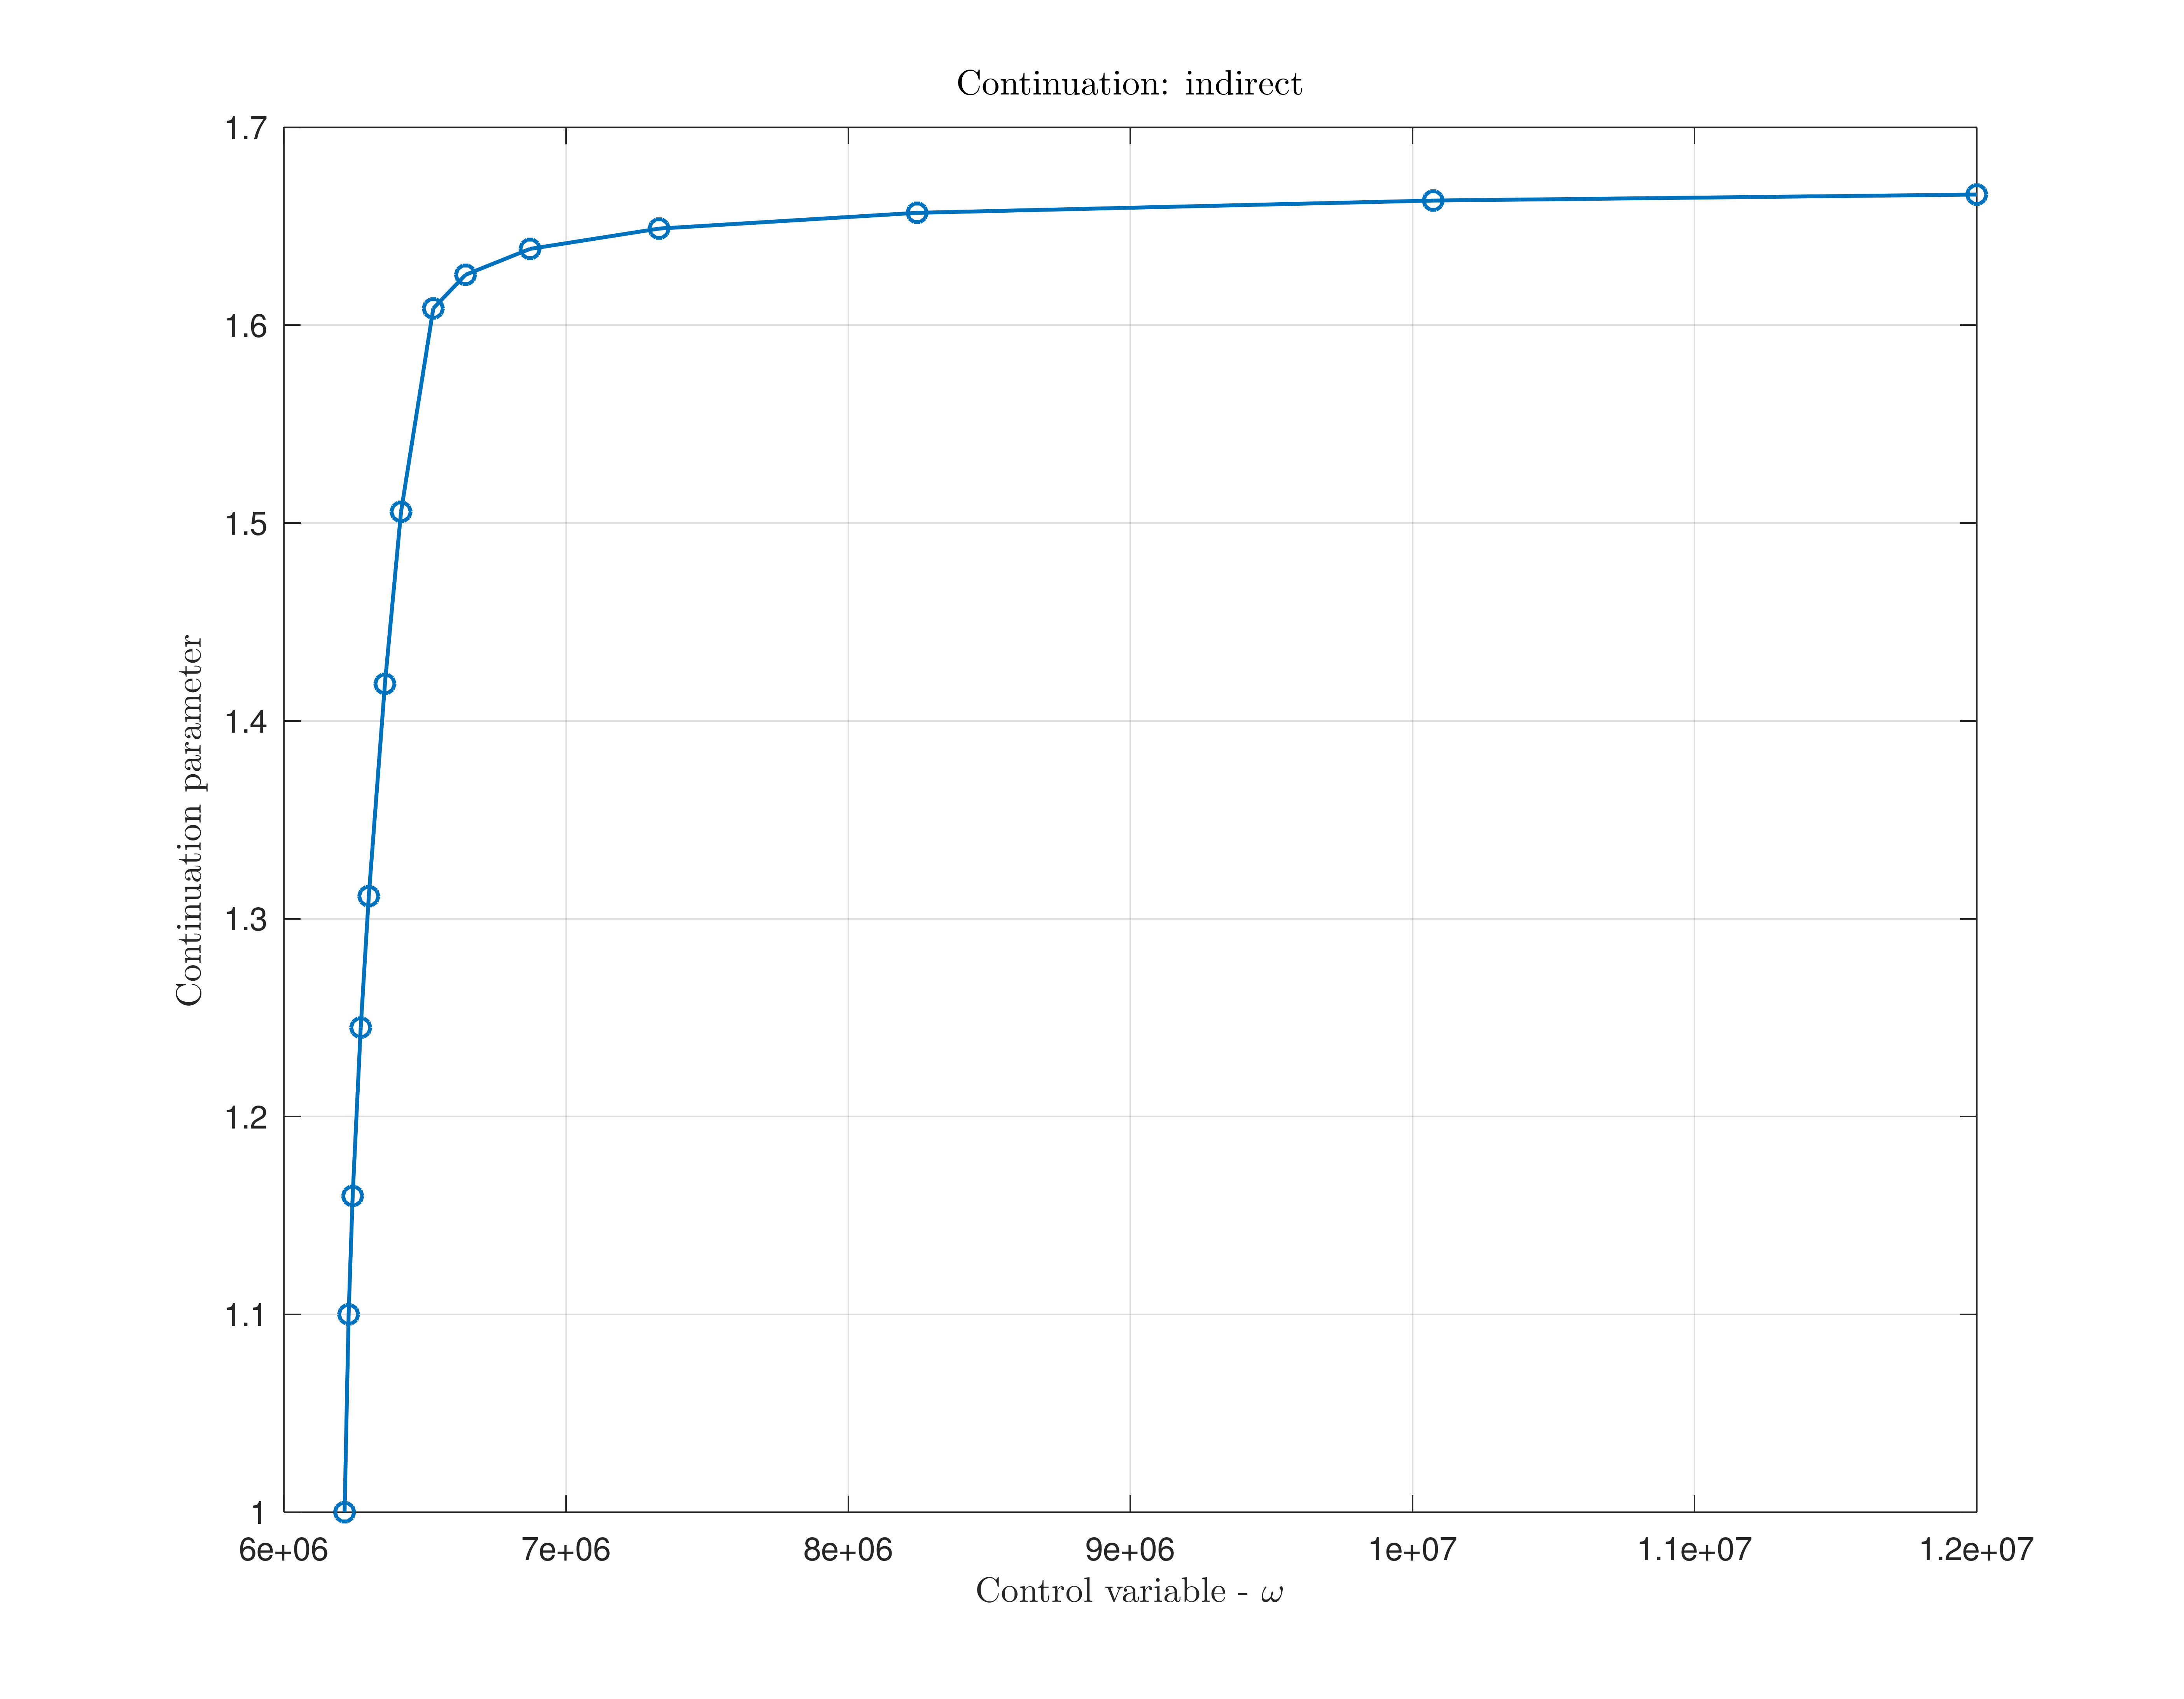

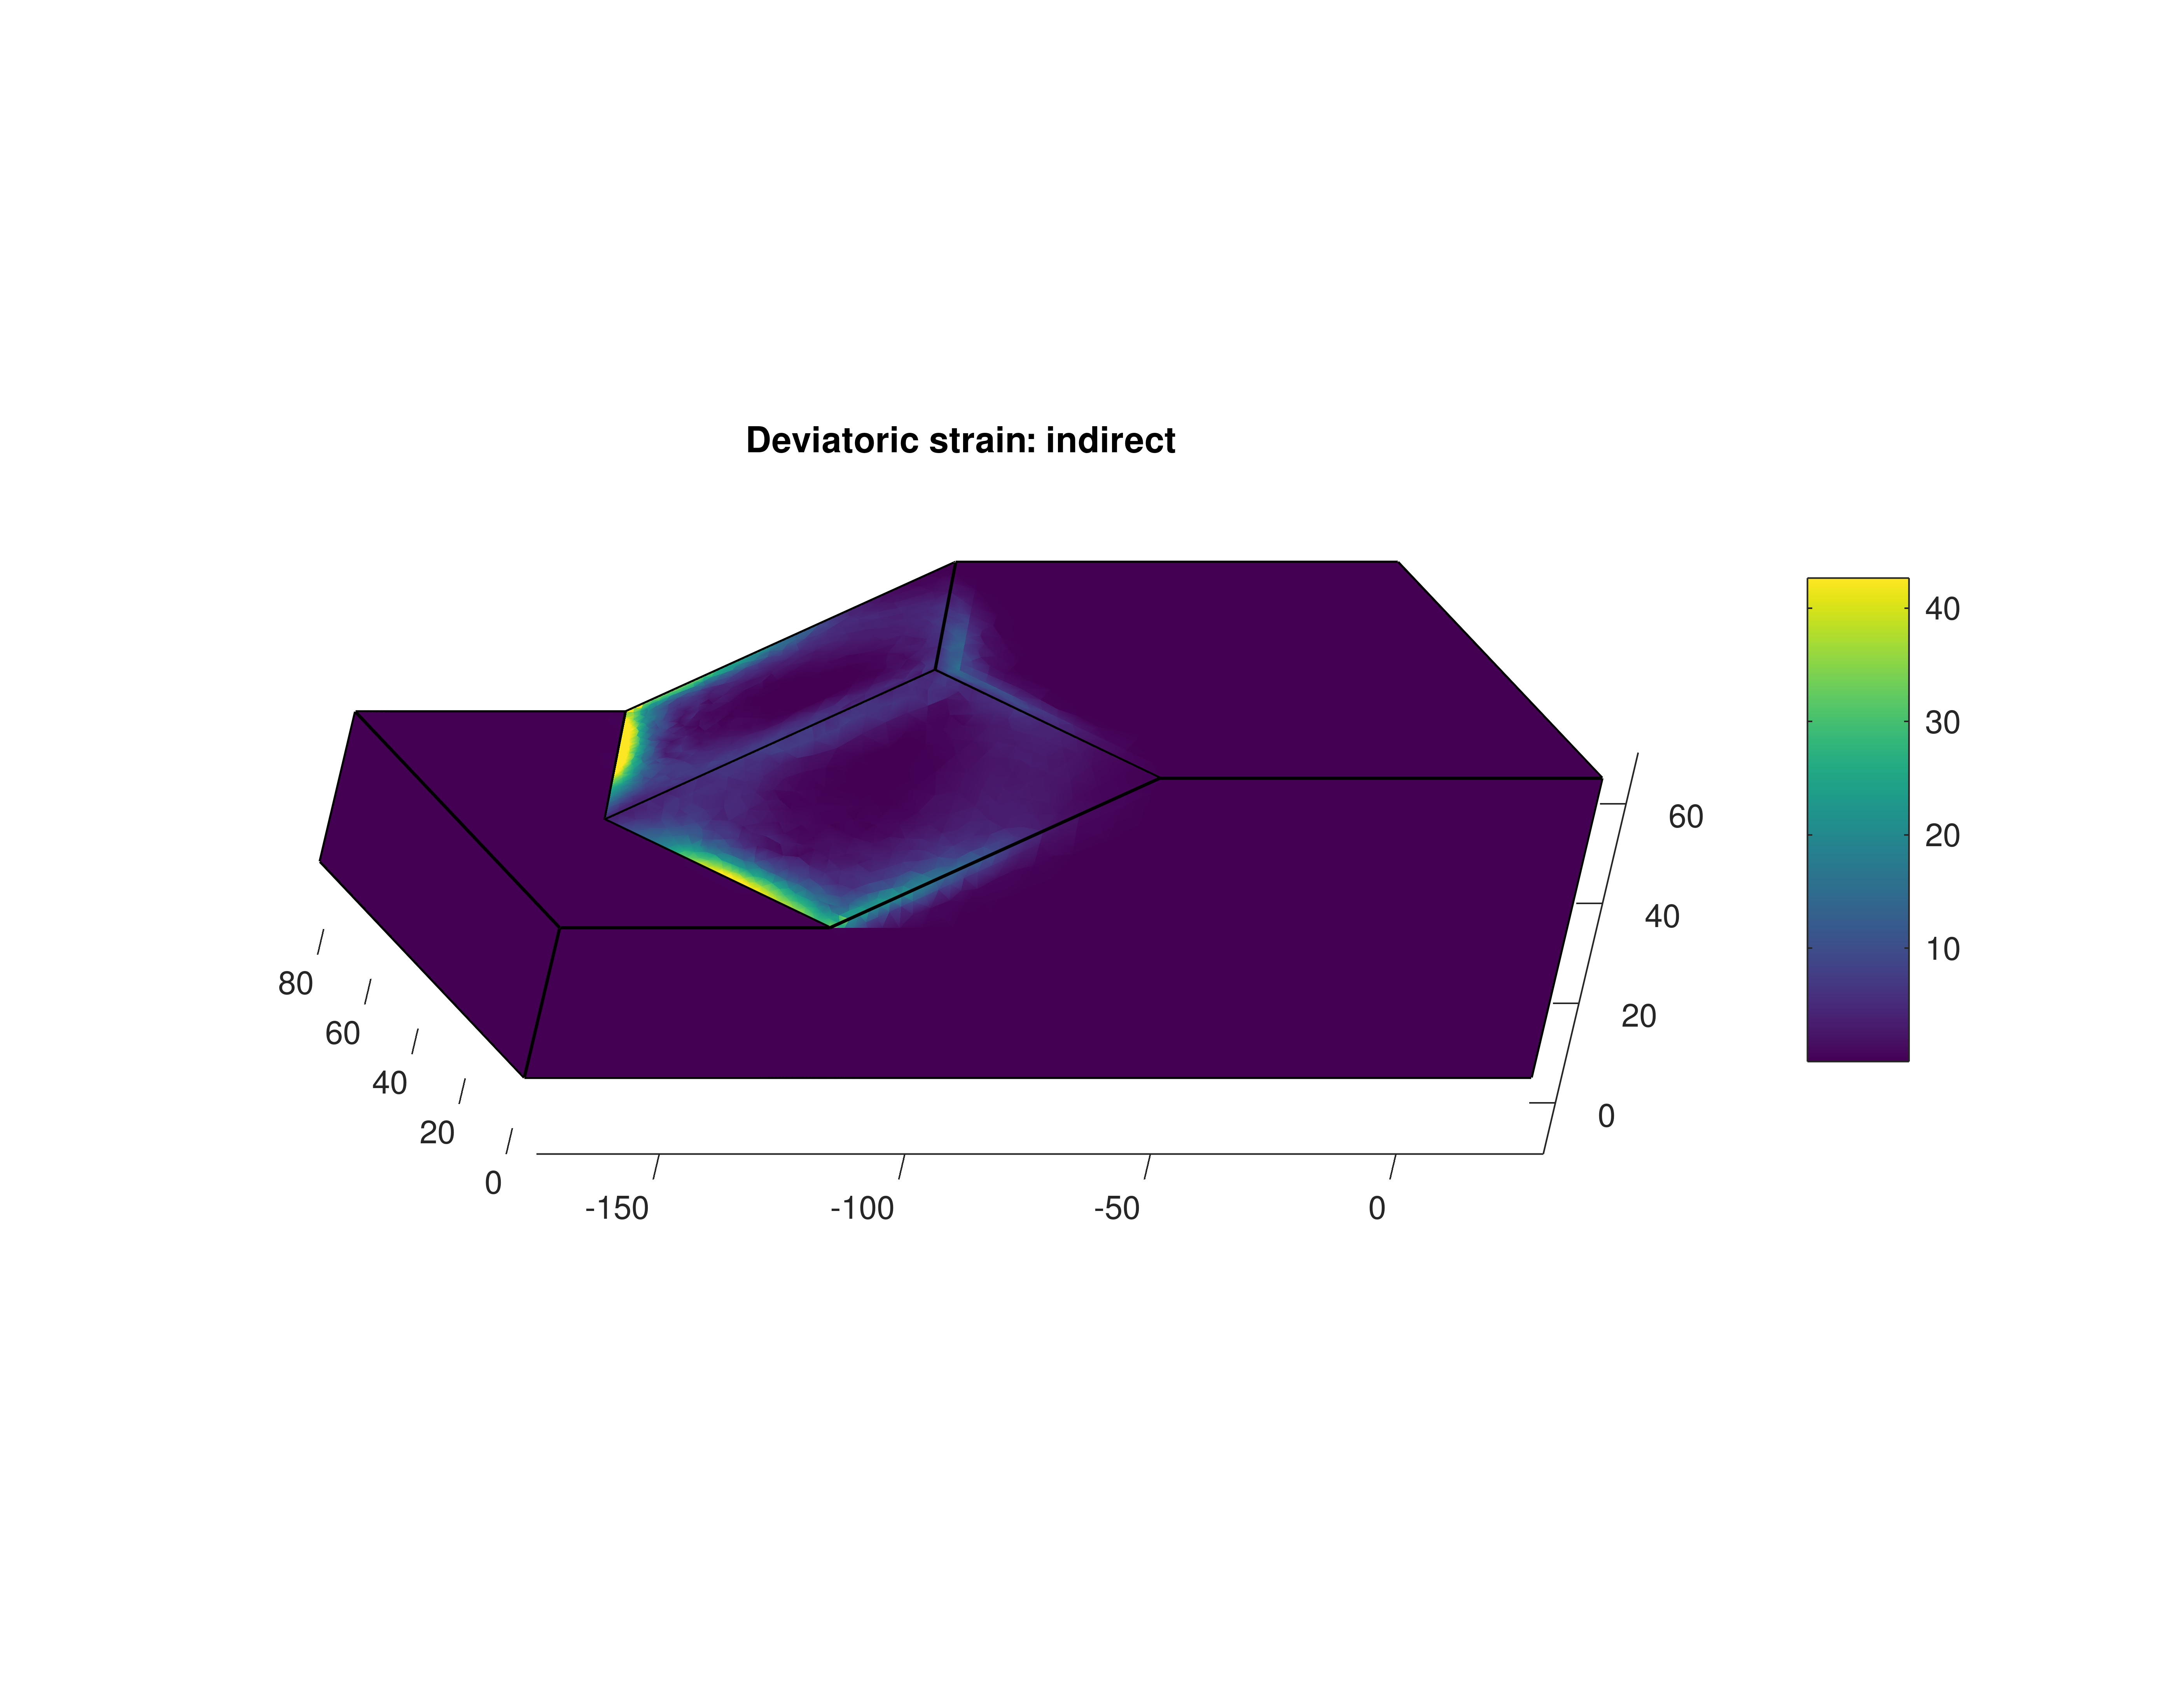

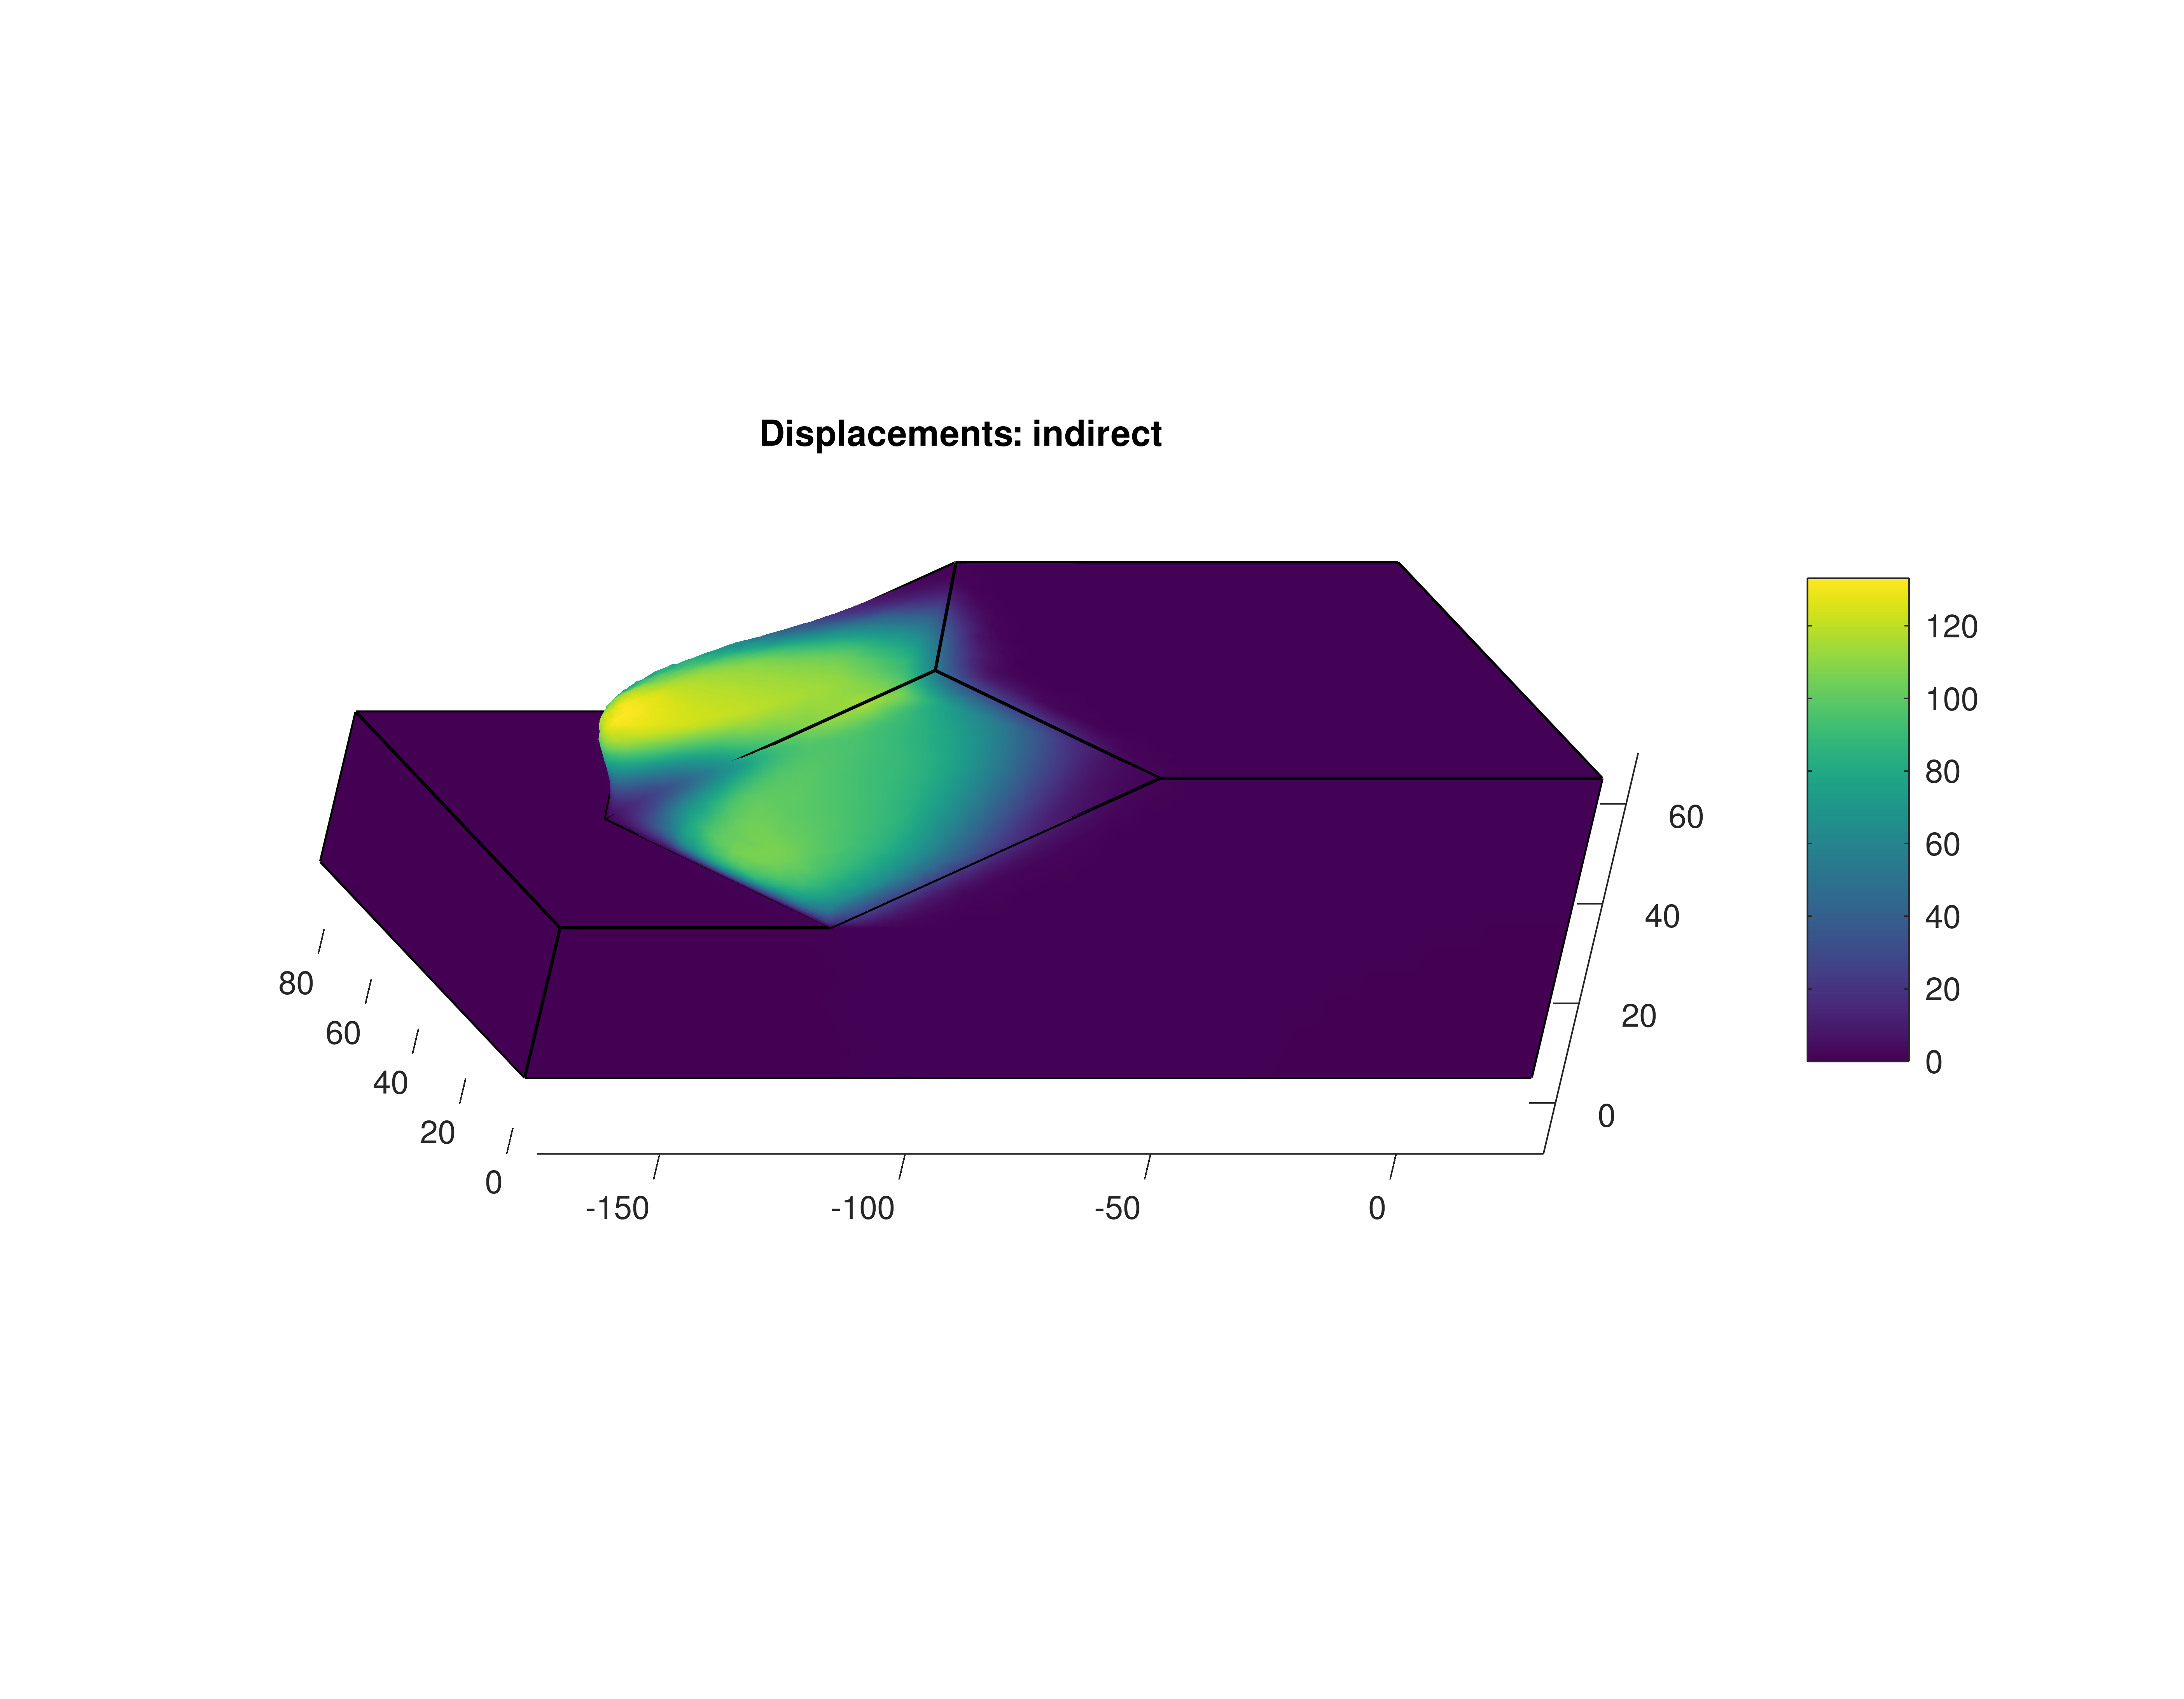

In [10]:
if indirect_on
    plotter.add_solution('indirect', U3, lambda_hist3, omega_hist3, Umax_hist3);
end

plotter.plot_displacements();
drawnow; pause(0.2);
plotter.plot_deviatoric_strain(0.75);
drawnow; pause(0.2);
plotter.plot_convergence();

fprintf('Notebook workflow completed.\n');
